### MODELO RANDOM FOREST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay

# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings
import zipfile
import os
from sklearn.ensemble import RandomForestClassifier
from utils import get_classifier_metrics


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [3]:
# Lectura directa desde los archivos .zip
X_train = pd.read_csv('../data/processed/X_train_obj1-targetE.zip')
X_test = pd.read_csv('../data/processed/X_test_obj1-targetE.zip')
y_train = pd.read_csv('../data/processed/y_train_obj1-targetE.zip')
y_test = pd.read_csv('../data/processed/y_test_obj1-targetE.zip')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [4]:
X_train.shape


(496076, 19)

In [5]:
X_test.shape


(124019, 19)

In [6]:
y_train.shape


(496076, 1)

In [7]:
y_test.shape


(124019, 1)

In [8]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)



In [9]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {"X_train": X_train,"X_test": X_test,"y_train": y_train, "y_test": y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f"{nombre}: {total_nulos} nulos encontrados.")
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f"{nombre}: No está cargado (es None)."

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


In [19]:
model_forest_clas = RandomForestClassifier(n_estimators=100,    # Número de árboles
                                           max_depth=10,        # Limitamos la profundidad para evitar overfitting
                                           class_weight='balanced', 
                                           random_state=42,
                                           n_jobs=-1)
model_forest_clas.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred_test = model_forest_clas.predict(X_test)
y_pred_train = model_forest_clas.predict(X_train)

In [21]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.553224,0.553224,0.553224,0.553224
Test set,0.508777,0.508777,0.508777,0.508777


In [22]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average='weighted')

,Accuracy,F1 Score,Precision,Recall
Train set,0.553224,0.553368,0.553706,0.553224
Test set,0.508777,0.508919,0.509218,0.508777


Top 15 variables más importantes:
            Variable  Importancia
18            Ticker     0.121249
8       Price_Change     0.077812
9       Volume_Ratio     0.064988
6        BB_Position     0.062205
15         RSI_lag_1     0.062048
5                RSI     0.056015
13      Volume_lag_5     0.045483
12      Volume_lag_3     0.045163
14     Volume_lag_10     0.044650
11      Volume_lag_2     0.043956
10      Volume_lag_1     0.043680
3               MACD     0.042436
1             Volume     0.042331
0              Close     0.042315
17  Volatility_lag_1     0.042305


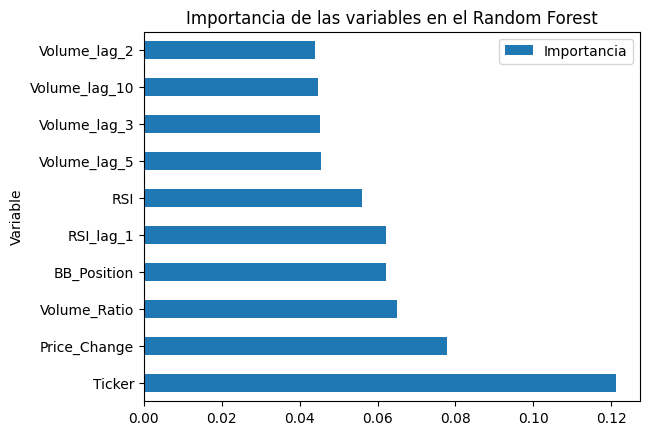

In [24]:
# Extraer importancia de las variables
# esto es para ver qué está mirando el modelo realmente
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': model_forest_clas.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Top 15 variables más importantes:")
print(importancias.head(15))

# Graficar
importancias.head(10).plot(kind='barh', x='Variable', y='Importancia')
plt.title("Importancia de las variables en el Random Forest")
plt.show()

In [ ]:
#TODO saray: seguir desde aqui cambiando y mejorando el modelo. 

### Conclusión:

## Hiperparametrización

In [25]:
# Definir hiperparámetros a probar
hparam_foreclas = {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 10],
                   'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4]}

# Implementar GridSearchCV
grid_search_foreclas = GridSearchCV(RandomForestClassifier(random_state=18),
                                hparam_foreclas,
                                cv=5,
                                n_jobs=-1,
                                verbose=1)

# Entrenamos
grid_search_foreclas.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
grid_search_foreclas.best_params_

Fitting 5 folds for each of 81 candidates, totalling 405 fits


KeyboardInterrupt: 

### Best Estimator

In [ ]:
# Mejor modelo
grid_search_foreclas.best_estimator_

In [ ]:
# Entrenamos
grid_search_foreclas.best_estimator_.fit(X_train, y_train)

In [ ]:
y_pred_test_grid = grid_search_foreclas.best_estimator_.predict(X_test)
y_pred_train_grid = grid_search_foreclas.best_estimator_.predict(X_train)

In [ ]:
#Random Forest Hiperparametrizado - métricas.
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train)

In [ ]:
# Defino los valores de n_estimators a probar (de 10 a 200) ya que el mejor dado por la hiper parametrización es el 100.
n_estimators_range = np.arange(10, 201, 20) 

# Calculo la curva de validación, fijando los MEJORES HIPERPARÁMETROS antes realizados.
train_scores, test_scores = validation_curve(RandomForestClassifier(random_state=18,
                                                                    criterion='gini',
                                                                    max_depth=5,
                                                                    min_samples_leaf=1,
                                                                    min_samples_split=2),
                                                                    X_train, y_train, 
                                                                    param_name="n_estimators", 
                                                                    param_range=n_estimators_range, 
                                                                    cv=5, 
                                                                    scoring="accuracy",
                                                                    n_jobs=-1)

# 3. Calculo la media y desviación estándar de los scores.
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 4. Grafico la evolución.
plt.figure(figsize=(10, 6))
plt.title("Evolución de Accuracy vs. n_estimators")
plt.xlabel("Número de Árboles (n_estimators)")
plt.ylabel("Puntuación (Accuracy)")
plt.grid(True)

# Curva de entrenamiento.
plt.plot(n_estimators_range, train_scores_mean, 
         label="Puntuación de Entrenamiento (Train)", color="blue", lw=2)

# Curva de validación (test).
plt.plot(n_estimators_range, test_scores_mean, 
         label="Puntuación de Validación (Test)", color="green", lw=2)

# Relleno el área de desviación estándar.
plt.fill_between(n_estimators_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="green")

plt.legend(loc="best")
plt.show()

In [ ]:
# 1. Defino los valores de max_depth a probar (eje X).
# Se prueba desde 1 hasta 15 de profundidad ya que el mejor dato dato en la hiperparametrización es el 5.
max_depth_range = np.arange(1, 16) 

# 2. Calculo la curva de validación.
# Uso un n_estimators fijo, el 100 que es el que sale en el mejor hiper parametro.
train_scores, test_scores = validation_curve(RandomForestClassifier(random_state=18,
                                                                    n_estimators=100,
                                                                    criterion='gini',
                                                                    max_depth=5,
                                                                    min_samples_leaf=1,
                                                                    min_samples_split=2),
                                                                    X_train, y_train, 
                                                                    param_name="max_depth", 
                                                                    param_range=max_depth_range,
                                                                    cv=5, 
                                                                    scoring="accuracy",
                                                                    n_jobs=-1)

# 3. Calcular la media de los scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)


# 4. Graficar la evolución
plt.figure(figsize=(10, 6))
plt.title("Evolución de Accuracy vs. max_depth")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("Puntuación (Accuracy)")
plt.grid(True)

plt.plot(max_depth_range, train_scores_mean, 
         label="Puntuación de Entrenamiento", color="blue", lw=2)

plt.plot(max_depth_range, test_scores_mean, 
         label="Puntuación de Validación (Test)", color="green", lw=2)

plt.fill_between(max_depth_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="green")

plt.legend(loc="best")
plt.show()

In [ ]:
# Obtener el mejor modelo
best_model = grid_search_foreclas.best_estimator_

# Hacer predicciones con el mejor modelo
y_pred_best_insu = best_model.predict(X_test)

# Matriz de confusión
conf_matrix = confusion_matrix(y_test,
                                    y_pred_best_insu)


# Visualización
class_names = ["Negativo", "Positivo"]
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión  (Random Forest Optimizado)")
plt.show()

In [ ]:
with open('../models/random_forest_clas.pkl', 'wb') as file:
    pickle.dump(best_model, file)

## Conclusión 